# Import Libraries

In [1]:
import re
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from nltk.stem import PorterStemmer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Define the Intents Dataset

In [2]:
intents = {
    "greeting": {
        "patterns": [
            "hi", "hello", "hey there", "good morning", "good evening",
            "hey", "what's up", "howdy", "hi there", "hello bot",
        ],
        "responses": [
            "Hello! How can I help you today?",
            "Hi there! What can I do for you?",
            "Hey! Ask me anything.",
        ],
    },
    "goodbye": {
        "patterns": [
            "bye", "goodbye", "see you later", "talk to you soon", "i have to go",
            "catch you later", "farewell", "see ya", "gotta go", "exit",
        ],
        "responses": [
            "Goodbye! Have a great day.",
            "See you next time!",
            "Bye! Feel free to come back anytime.",
        ],
    },
    "thanks": {
        "patterns": [
            "thanks", "thank you", "thanks a lot", "appreciate it", "thank you so much",
            "many thanks", "thanks for the help", "thx", "great, thanks", "cheers",
        ],
        "responses": [
            "You're welcome!",
            "Happy to help!",
            "Anytime!",
        ],
    },
    "bot_name": {
        "patterns": [
            "what is your name", "who are you", "what should i call you",
            "do you have a name", "tell me your name", "what are you called",
            "your name please", "who am i talking to", "what's your name",
            "introduce yourself",
        ],
        "responses": [
            "I'm NovaBot, your virtual assistant!",
            "You can call me NovaBot.",
            "I'm an AI chatbot here to help you.",
        ],
    },
    "hours": {
        "patterns": [
            "what are your business hours", "when are you open", "what time do you open",
            "what time do you close", "are you open now", "opening hours",
            "when do you close", "what hours do you operate", "are you open on weekends",
            "when can i visit",
        ],
        "responses": [
            "We're open Monday to Saturday, 9 AM to 6 PM.",
            "Our business hours are 9 AM - 6 PM, Monday through Saturday.",
        ],
    },
    "location": {
        "patterns": [
            "where are you located", "what is your address", "where is your office",
            "how do i get to your office", "what city are you in", "where can i find you",
            "do you have a physical location", "where is your store", "your location please",
            "what's your address",
        ],
        "responses": [
            "We're located at 123 Main Street, Springfield.",
            "Our office is at 123 Main Street, Springfield.",
        ],
    },
    "help": {
        "patterns": [
            "what can you do", "help me", "how do you work", "what are your features",
            "can you help", "what services do you offer", "how can you assist me",
            "what do you do", "list your capabilities", "i need help",
        ],
        "responses": [
            "I can answer questions, chat with you, and help you book an appointment. Just ask!",
            "I can chat, answer common questions, and schedule appointments for you.",
        ],
    },
    "book_appointment": {
        "patterns": [
            "i want to book an appointment", "can i schedule a meeting", "book an appointment",
            "i'd like to make a booking", "schedule an appointment for me", "can you book a slot",
            "i need to set up an appointment", "reserve a time slot", "make a reservation",
            "schedule a visit",
        ],
        "responses": [
            "Sure, I can help you book an appointment!",
        ],
    },
}

print(f"Total intents defined: {len(intents)}")
for name, data in intents.items():
    print(f"  - {name}: {len(data['patterns'])} example patterns")

Total intents defined: 8
  - greeting: 10 example patterns
  - goodbye: 10 example patterns
  - thanks: 10 example patterns
  - bot_name: 10 example patterns
  - hours: 10 example patterns
  - location: 10 example patterns
  - help: 10 example patterns
  - book_appointment: 10 example patterns


# Build a Training Dataset from the Intents

In [3]:
rows = []
for intent_name, data in intents.items():
    for pattern in data["patterns"]:
        rows.append({"text": pattern, "intent": intent_name})

df = pd.DataFrame(rows)
print("Training dataset shape:", df.shape)
df.sample(10, random_state=RANDOM_STATE)

Training dataset shape: (80, 2)


,text,intent
30,what is your name,bot_name
0,hi,greeting
22,thanks a lot,thanks
31,who are you,bot_name
18,gotta go,goodbye
28,"great, thanks",thanks
10,bye,goodbye
70,i want to book an appointment,book_appointment
4,good evening,greeting
12,see you later,goodbye


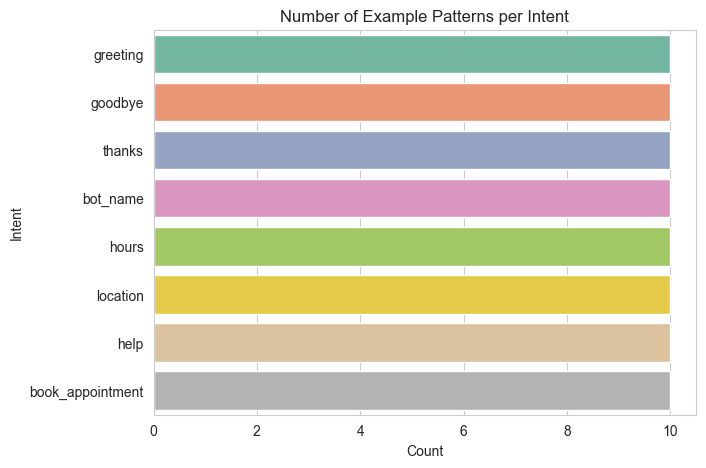

In [4]:
plt.figure()
sns.countplot(data=df, y="intent", hue="intent", order=df["intent"].value_counts().index,
              palette="Set2", legend=False)
plt.title("Number of Example Patterns per Intent")
plt.xlabel("Count")
plt.ylabel("Intent")
plt.show()

# Preprocess User Input (NLP Techniques)

In [5]:
stemmer = PorterStemmer()
STOPWORDS = set(ENGLISH_STOP_WORDS) - {"what", "when", "where", "who", "how", "why", "your", "you"}

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if w not in STOPWORDS]
    tokens = [stemmer.stem(w) for w in tokens]
    return " ".join(tokens)


df["clean_text"] = df["text"].apply(preprocess)
df[["text", "clean_text", "intent"]].head(10)

,text,clean_text,intent
0,hi,hi,greeting
1,hello,hello,greeting
2,hey there,hey,greeting
3,good morning,good morn,greeting
4,good evening,good even,greeting
5,hey,hey,greeting
6,what's up,what s,greeting
7,howdy,howdi,greeting
8,hi there,hi,greeting
9,hello bot,hello bot,greeting


# Train the Intent Recognition Model

In [6]:
X = df["clean_text"]
y = df["intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

tfidf = TfidfVectorizer(ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# C=10 sharpens predict_proba confidence scores so the fallback threshold behaves
# meaningfully even with a small, evenly-balanced training set like this one.
intent_model = LogisticRegression(max_iter=1000, C=10, random_state=RANDOM_STATE)
intent_model.fit(X_train_tfidf, y_train)

print("Intent classifier trained.")
print("Classes:", list(intent_model.classes_))

Intent classifier trained.
Classes: ['book_appointment', 'bot_name', 'goodbye', 'greeting', 'help', 'hours', 'location', 'thanks']


# Evaluate the Intent Classifier

Accuracy (held-out test set): 0.8500
F1-Score (macro):             0.8238

Classification Report:
                   precision    recall  f1-score   support

book_appointment       0.67      1.00      0.80         2
        bot_name       0.67      1.00      0.80         2
         goodbye       0.75      1.00      0.86         3
        greeting       1.00      1.00      1.00         3
            help       1.00      0.67      0.80         3
           hours       1.00      0.50      0.67         2
        location       1.00      1.00      1.00         3
          thanks       1.00      0.50      0.67         2

        accuracy                           0.85        20
       macro avg       0.89      0.83      0.82        20
    weighted avg       0.90      0.85      0.84        20



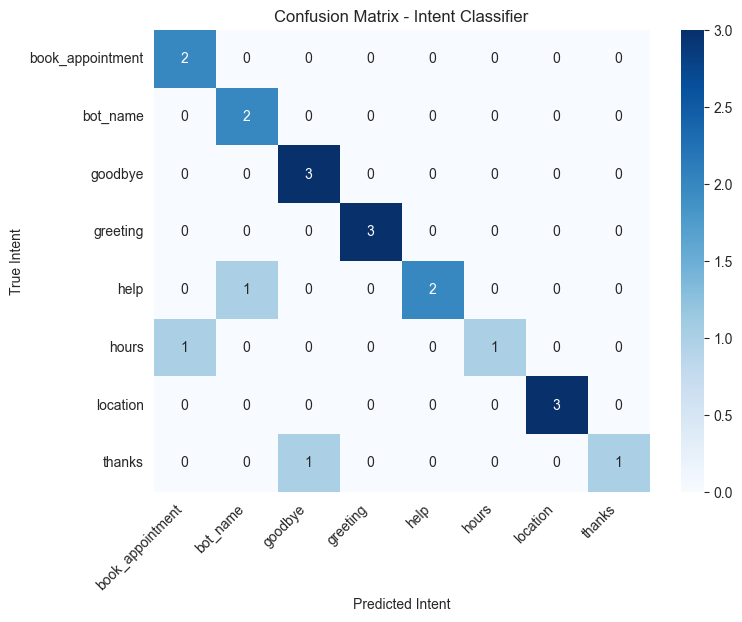

In [7]:
y_pred = intent_model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy (held-out test set): {acc:.4f}")
print(f"F1-Score (macro):             {f1_macro:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=intent_model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=intent_model.classes_, yticklabels=intent_model.classes_)
plt.title("Confusion Matrix - Intent Classifier")
plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")
plt.xticks(rotation=45, ha="right")
plt.show()

In [8]:
def predict_intent(text, threshold=0.35):
    """Returns (intent, confidence). Falls back to 'fallback' if confidence is too low."""
    cleaned = preprocess(text)
    vec = tfidf.transform([cleaned])
    proba = intent_model.predict_proba(vec)[0]
    best_idx = np.argmax(proba)
    best_intent = intent_model.classes_[best_idx]
    confidence = proba[best_idx]

    if confidence < threshold:
        return "fallback", confidence
    return best_intent, confidence


for msg in ["hey there!", "what time do you guys close", "book me a slot please", "asdkjahsdkjh"]:
    intent, conf = predict_intent(msg)
    print(f"'{msg}'  -->  intent: {intent:<18} confidence: {conf:.3f}")

'hey there!'  -->  intent: greeting           confidence: 0.754
'what time do you guys close'  -->  intent: hours              confidence: 0.708
'book me a slot please'  -->  intent: book_appointment   confidence: 0.832
'asdkjahsdkjh'  -->  intent: fallback           confidence: 0.179


# Entity Extraction for Slot Filling

In [9]:
DAY_WORDS = [
    "today", "tomorrow", "monday", "tuesday", "wednesday",
    "thursday", "friday", "saturday", "sunday", "next week",
]

def extract_date(text):
    text_lower = text.lower()
    for day in DAY_WORDS:
        if day in text_lower:
            return day
    # fallback: look for patterns like "12th", "march 5", "5/12"
    match = re.search(r"\b(\d{1,2}(st|nd|rd|th)?\s?(of)?\s?[a-zA-Z]*|\d{1,2}/\d{1,2})\b", text_lower)
    return match.group(0).strip() if match else None


def extract_time(text):
    match = re.search(r"\b(\d{1,2}(:\d{2})?\s?(am|pm)?)\b", text.lower())
    if match and (match.group(3) or ":" in match.group(0)):
        return match.group(0).strip()
    return None


print(extract_date("can we do tomorrow"), "|", extract_time("how about 3pm"))
print(extract_date("let's say next friday"), "|", extract_time("15:30 works for me"))

tomorrow | 3pm
friday | 15:30


# Response Generation & Multi-Turn Conversation Flow Management

In [10]:
def new_session():
    return {"flow": None, "step": None, "slots": {}}


def generate_response(message, session):
    """Given a user message and the current session state, returns (response, updated_session, intent_used)."""

    # --- Handle an in-progress multi-turn flow first ---
    if session["flow"] == "book_appointment":
        step = session["step"]

        if step == "ask_name":
            session["slots"]["name"] = message.strip().title()
            session["step"] = "ask_date"
            return (f"Nice to meet you, {session['slots']['name']}! "
                    f"What date works best for your appointment?"), session, "booking_flow"

        if step == "ask_date":
            date = extract_date(message) or message.strip()
            session["slots"]["date"] = date
            session["step"] = "ask_time"
            return f"Got it, {date}. What time would you prefer?", session, "booking_flow"

        if step == "ask_time":
            time_ = extract_time(message) or message.strip()
            session["slots"]["time"] = time_
            session["step"] = "confirm"
            slots = session["slots"]
            return (f"Just to confirm: book an appointment for {slots['name']} "
                    f"on {slots['date']} at {slots['time']}. Shall I confirm this? (yes/no)"), session, "booking_flow"

        if step == "confirm":
            if message.strip().lower() in ("yes", "y", "yeah", "confirm", "sure", "yep"):
                slots = session["slots"]
                response = (f"✅ Your appointment is confirmed for {slots['date']} at {slots['time']}, "
                            f"{slots['name']}. See you then!")
            else:
                response = "No problem, I've cancelled that booking. Let me know if you'd like to try again."
            session = new_session()  # reset session after flow completes
            return response, session, "booking_flow"

    # --- No active flow: classify intent normally ---
    intent, confidence = predict_intent(message)

    if intent == "book_appointment":
        session["flow"] = "book_appointment"
        session["step"] = "ask_name"
        response = random.choice(intents["book_appointment"]["responses"]) + " What's your name?"
        return response, session, intent

    if intent == "fallback":
        response = ("I'm not sure I understood that. Could you rephrase, or ask about our "
                    "hours, location, or booking an appointment?")
        return response, session, intent

    response = random.choice(intents[intent]["responses"])
    return response, session, intent

# Simulate Conversations (Multiple Flows)

In [11]:
def run_conversation(turns, title):
    session = new_session()
    print("=" * 70)
    print(title)
    print("=" * 70)
    log = []
    for user_msg in turns:
        response, session, intent_used = generate_response(user_msg, session)
        print(f"User: {user_msg}")
        print(f"Bot : {response}\n")
        log.append({"user_message": user_msg, "bot_response": response, "intent_used": intent_used})
    return log


faq_conversation = [
    "hi there",
    "what are your business hours",
    "where are you located",
    "thanks a lot",
    "bye",
]
faq_log = run_conversation(faq_conversation, "CONVERSATION 1: FAQ-Style Chat")

CONVERSATION 1: FAQ-Style Chat
User: hi there
Bot : Hey! Ask me anything.

User: what are your business hours
Bot : We're open Monday to Saturday, 9 AM to 6 PM.

User: where are you located
Bot : We're located at 123 Main Street, Springfield.

User: thanks a lot
Bot : Anytime!

User: bye
Bot : See you next time!



In [12]:
booking_conversation = [
    "hello",
    "i want to book an appointment",
    "John Smith",
    "next friday",
    "3pm",
    "yes",
]
booking_log = run_conversation(booking_conversation, "CONVERSATION 2: Multi-Turn Appointment Booking")

CONVERSATION 2: Multi-Turn Appointment Booking
User: hello
Bot : Hello! How can I help you today?

User: i want to book an appointment
Bot : Sure, I can help you book an appointment! What's your name?

User: John Smith
Bot : Nice to meet you, John Smith! What date works best for your appointment?

User: next friday
Bot : Got it, friday. What time would you prefer?

User: 3pm
Bot : Just to confirm: book an appointment for John Smith on friday at 3pm. Shall I confirm this? (yes/no)

User: yes
Bot : ✅ Your appointment is confirmed for friday at 3pm, John Smith. See you then!



In [13]:
fallback_conversation = [
    "hey",
    "asdkjh qwoieuqwoe zzz",
    "what can you do",
    "goodbye",
]
fallback_log = run_conversation(fallback_conversation, "CONVERSATION 3: Handling Unrecognized Input")

CONVERSATION 3: Handling Unrecognized Input
User: hey
Bot : Hello! How can I help you today?

User: asdkjh qwoieuqwoe zzz
Bot : I'm not sure I understood that. Could you rephrase, or ask about our hours, location, or booking an appointment?

User: what can you do
Bot : I'm an AI chatbot here to help you.

User: goodbye
Bot : Goodbye! Have a great day.



# Evaluate Chatbot Accuracy & User-Interaction Quality

In [14]:
evaluation_turns = [
    ("hi there", "greeting", True),
    ("what are your business hours", "hours", False),
    ("where are you located", "location", False),
    ("thanks a lot", "thanks", False),
    ("bye", "goodbye", False),

    ("hello", "greeting", True),
    ("i want to book an appointment", "book_appointment", False),
    ("John Smith", "booking_flow", False),
    ("next friday", "booking_flow", False),
    ("3pm", "booking_flow", False),
    ("yes", "booking_flow", False),

    ("hey", "greeting", True),
    ("asdkjh qwoieuqwoe zzz", "fallback", False),
    ("what can you do", "help", False),
    ("goodbye", "goodbye", False),
]

session = new_session()
correct = 0
eval_rows = []

for user_msg, expected_intent, is_new_session in evaluation_turns:
    if is_new_session:
        session = new_session()
    response, session, intent_used = generate_response(user_msg, session)
    is_correct = (intent_used == expected_intent)
    correct += int(is_correct)
    eval_rows.append({
        "user_message": user_msg,
        "expected_intent": expected_intent,
        "predicted_intent_used": intent_used,
        "correct": is_correct,
    })

eval_df = pd.DataFrame(eval_rows)
turn_level_accuracy = correct / len(evaluation_turns)

print(f"Turn-level interaction accuracy across simulated conversations: {turn_level_accuracy:.2%}\n")
eval_df

Turn-level interaction accuracy across simulated conversations: 93.33%



,user_message,expected_intent,predicted_intent_used,correct
0,hi there,greeting,greeting,True
1,what are your business hours,hours,hours,True
2,where are you located,location,location,True
3,thanks a lot,thanks,thanks,True
4,bye,goodbye,goodbye,True
5,hello,greeting,greeting,True
6,i want to book an appointment,book_appointment,book_appointment,True
7,John Smith,booking_flow,booking_flow,True
8,next friday,booking_flow,booking_flow,True
9,3pm,booking_flow,booking_flow,True


Fallback rate across evaluated turns: 6.67%


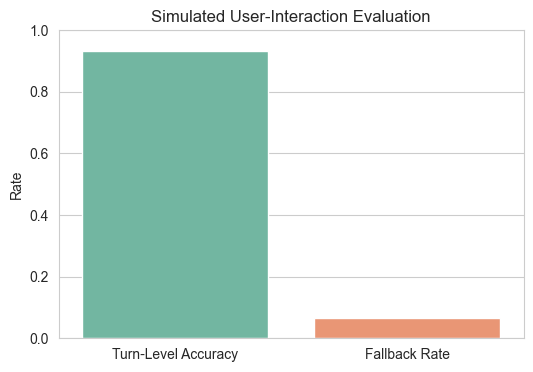

In [15]:
fallback_rate = (eval_df["predicted_intent_used"] == "fallback").mean()
print(f"Fallback rate across evaluated turns: {fallback_rate:.2%}")

plt.figure(figsize=(6, 4))
sns.barplot(x=["Turn-Level Accuracy", "Fallback Rate"],
            y=[turn_level_accuracy, fallback_rate],
            hue=["Turn-Level Accuracy", "Fallback Rate"],
            palette="Set2", legend=False)
plt.ylim(0, 1)
plt.title("Simulated User-Interaction Evaluation")
plt.ylabel("Rate")
plt.show()

# (Optional) Live Interactive Mode

In [16]:
def run_interactive_chat():
    session = new_session()
    print("NovaBot: Hi! Type 'quit' to exit.")
    while True:
        user_msg = input("You: ")
        if user_msg.strip().lower() in ("quit", "exit"):
            print("NovaBot: Goodbye!")
            break
        response, session, _ = generate_response(user_msg, session)
        print(f"NovaBot: {response}")

# Defined but NOT called automatically - call run_interactive_chat() yourself to chat live.
print("run_interactive_chat() is ready. Call it in a new cell to start a live conversation.")

run_interactive_chat() is ready. Call it in a new cell to start a live conversation.
